# Experiment - Predict Churn or No Churn
Use ML models and tabular data to predict if a customer will churn or not.

# 0. Import Libraries and Load Data

In [11]:
# Data Analysis
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme()

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

import lightgbm as lgb
import xgboost as xgb

from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, learning_curve
from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.pipeline import Pipeline

from sklearn.compose import ColumnTransformer

In [3]:
df = pd.read_csv("../data/Telco_customer_churn.csv")

print(df.shape)
display(df)

(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


# 1. Preprocess Data

In [4]:
# Select useful columns, as seen in the data analysis step
columns = ['SeniorCitizen', 'Partner', 'Dependents', 'tenure',
           'InternetService', 'OnlineSecurity', 'OnlineBackup',
           'DeviceProtection', 'TechSupport', 'StreamingTV',
           'StreamingMovies', 'Contract', 'PaperlessBilling',
           'PaymentMethod', 'MonthlyCharges', 'Churn']

df = df[columns]

# Cast Yes/No variables to binary
yes_no_columns = ['Partner', 'Dependents', 'PaperlessBilling', 'Churn']

for column in yes_no_columns:
    df[column] = df[column].map({'Yes': 1, 'No': 0}).astype(int)

print(df.info())
display(df)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   SeniorCitizen     7043 non-null   int64  
 1   Partner           7043 non-null   int32  
 2   Dependents        7043 non-null   int32  
 3   tenure            7043 non-null   int64  
 4   InternetService   7043 non-null   object 
 5   OnlineSecurity    7043 non-null   object 
 6   OnlineBackup      7043 non-null   object 
 7   DeviceProtection  7043 non-null   object 
 8   TechSupport       7043 non-null   object 
 9   StreamingTV       7043 non-null   object 
 10  StreamingMovies   7043 non-null   object 
 11  Contract          7043 non-null   object 
 12  PaperlessBilling  7043 non-null   int32  
 13  PaymentMethod     7043 non-null   object 
 14  MonthlyCharges    7043 non-null   float64
 15  Churn             7043 non-null   int32  
dtypes: float64(1), int32(4), int64(2), object(

,SeniorCitizen,Partner,Dependents,tenure,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,Churn
0,0,1,0,1,DSL,No,Yes,No,No,No,No,Month-to-month,1,Electronic check,29.85,0
1,0,0,0,34,DSL,Yes,No,Yes,No,No,No,One year,0,Mailed check,56.95,0
2,0,0,0,2,DSL,Yes,Yes,No,No,No,No,Month-to-month,1,Mailed check,53.85,1
3,0,0,0,45,DSL,Yes,No,Yes,Yes,No,No,One year,0,Bank transfer (automatic),42.30,0
4,0,0,0,2,Fiber optic,No,No,No,No,No,No,Month-to-month,1,Electronic check,70.70,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,0,1,1,24,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,1,Mailed check,84.80,0
7039,0,1,1,72,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,1,Credit card (automatic),103.20,0
7040,0,1,1,11,DSL,Yes,No,No,No,No,No,Month-to-month,1,Electronic check,29.60,0
7041,1,1,0,4,Fiber optic,No,No,No,No,No,No,Month-to-month,1,Mailed check,74.40,1


# 2. Helper Functions

In [5]:
def plot_learning_curve(
    train_sizes: np.ndarray,
    train_scores: np.ndarray,
    val_scores: np.ndarray,
    title: str = "Learning Curve",
) -> None:
    """Plots a learning curve showing PR-AUC vs. training set size.
 
    Displays mean ± 1 standard deviation bands for both training and
    validation scores across cross-validation folds. The gap between
    the two curves indicates whether the model suffers from high bias
    (both curves low) or high variance (large gap between curves).
 
    Args:
        train_sizes: Array of training subset sizes used to compute scores.
        train_scores: 2D array of shape (n_sizes, n_splits) with train PR-AUC.
        val_scores: 2D array of shape (n_sizes, n_splits) with val PR-AUC.
        title: Plot title. Defaults to "Learning Curve".
    """
    train_mean = train_scores.mean(axis=1)
    train_std  = train_scores.std(axis=1)
    val_mean   = val_scores.mean(axis=1)
    val_std    = val_scores.std(axis=1)
 
    _, ax = plt.subplots(figsize=(8, 5))
 
    # Training score band
    ax.plot(train_sizes, train_mean, "o-", color="#534AB7", label="Train PR-AUC")
    ax.fill_between(
        train_sizes,
        train_mean - train_std,
        train_mean + train_std,
        alpha=0.15,
        color="#534AB7",
    )
 
    # Validation score band
    ax.plot(train_sizes, val_mean, "o-", color="#1D9E75", label="Validation PR-AUC")
    ax.fill_between(
        train_sizes,
        val_mean - val_std,
        val_mean + val_std,
        alpha=0.15,
        color="#1D9E75",
    )
 
    ax.set_title(title, fontsize=13)
    ax.set_xlabel("Training set size")
    ax.set_ylabel("PR-AUC")
    ax.legend(loc="lower right")
    ax.set_ylim(0, 1)
    sns.despine()
    plt.tight_layout()
    plt.show()

# 3. Logistic Regression

In [12]:
def train_logistic_regression_churn(
    X: pd.DataFrame,
    y: pd.Series,
    n_splits: int = 5,
    random_state: int = 42,
    **kwargs
) -> dict:
    """Trains a Logistic Regression model for churn prediction using stratified k-fold CV.

    Uses StratifiedKFold to preserve the churn rate across folds, StandardScaler
    for feature normalization, and class_weight='balanced' to handle class imbalance
    without resampling. One-hot encoding is applied inside the CV loop using
    OneHotEncoder fitted only on the training fold, preventing data leakage from
    unseen categories. Evaluates each fold on PR-AUC (primary), ROC-AUC, precision,
    recall, and F1 for both the training fold and the validation fold.
    A large and persistent gap between train and val metrics indicates overfitting;
    similar low values on both indicate underfitting (high bias).

    Args:
        X: Feature matrix. May contain both numeric and categorical (object/category)
            columns — encoding is handled internally.
        y: Binary target series. 1 = churned, 0 = retained.
        n_splits: Number of folds for StratifiedKFold cross-validation. Defaults to 5.
        random_state: Random seed for reproducibility. Defaults to 42.
        **kwargs: Additional keyword arguments for LogisticRegression.

    Returns:
        A dict with the following keys:
            - "train_metrics" (pd.DataFrame): Per-fold scores on the training fold.
            - "val_metrics" (pd.DataFrame): Per-fold scores on the validation fold.
            - "train_mean" (pd.Series): Mean of each train metric across all folds.
            - "val_mean" (pd.Series): Mean of each val metric across all folds.
            - "train_std" (pd.Series): Std of each train metric across all folds.
            - "val_std" (pd.Series): Std of each val metric across all folds.
            - "models" (list[LogisticRegression]): Fitted model from each fold.
            - "scalers" (list[MinMaxScaler]): Fitted scaler from each fold.
            - "encoders" (list[OneHotEncoder]): Fitted encoder from each fold.
            - "feature_names" (list[str]): Feature names after encoding (from last fold).
            - "feature_importance" (pd.DataFrame): Mean absolute coefficient per
              feature, sorted descending.
            - "learning_curve" (dict): Contains "train_sizes", "train_scores",
              and "val_scores" arrays used to plot the learning curve.

    Raises:
        ValueError: If X and y have different numbers of rows.
        ValueError: If y contains values other than 0 and 1.

    Example:
        >>> result = train_logistic_regression_churn(X_raw, y, n_splits=5)
        >>> print(result["train_mean"])
        >>> print(result["val_mean"])
        >>> print(result["feature_importance"].head(10))
    """
    # ── Input validation ───────────────────────────────────────────────────────

    if len(X) != len(y):
        raise ValueError(
            f"X and y must have the same number of rows. "
            f"Got X={len(X)}, y={len(y)}."
        )

    unique_values = set(y.unique())
    
    if not unique_values.issubset({0, 1}):
        raise ValueError(
            f"y must contain only binary values (0 and 1). "
            f"Got: {unique_values}."
        )

    # ── Identify column types ──────────────────────────────────────────────────

    categorical_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
    numeric_cols     = X.select_dtypes(exclude=["object", "category"]).columns.tolist()

    # ── Cross-validation setup ─────────────────────────────────────────────────

    # StratifiedKFold preserves the churn rate in each fold,
    # which is critical for imbalanced targets.
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    # Storage for per-fold results — tracked separately for train and val
    train_fold_metrics = []
    val_fold_metrics   = []
    models    = []
    scalers   = []
    encoders  = []
    coef_matrix  = []
    feature_names = []

    # ── Training loop ──────────────────────────────────────────────────────────

    for fold, (train_idx, val_idx) in enumerate(cv.split(X, y), start=1):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

        # ── One-hot encoding — fit only on training fold ───────────────────────
        # Fitting the encoder on the full dataset would leak validation category
        # frequencies into the training process. handle_unknown="ignore" silently
        # zeros out any category in the validation fold not seen during training.
        if categorical_cols:
            encoder = OneHotEncoder(
                drop="first",              # avoid multicollinearity (k-1 dummies)
                sparse_output=False,
                handle_unknown="ignore",   # unseen categories become all-zero rows
            )
            X_train_cat = encoder.fit_transform(X_train[categorical_cols])
            X_val_cat   = encoder.transform(X_val[categorical_cols])

            ohe_feature_names = encoder.get_feature_names_out(categorical_cols).tolist()

            X_train_encoded = np.hstack([X_train[numeric_cols].values, X_train_cat])
            X_val_encoded   = np.hstack([X_val[numeric_cols].values,   X_val_cat])
            fold_feature_names = numeric_cols + ohe_feature_names
        else:
            # No categorical columns — pass through unchanged
            encoder            = None
            X_train_encoded    = X_train[numeric_cols].values
            X_val_encoded      = X_val[numeric_cols].values
            fold_feature_names = numeric_cols

        # Scale features — logistic regression is sensitive to feature magnitude.
        # Fit scaler only on training data to avoid data leakage.
        scaler         = MinMaxScaler()
        X_train_scaled = scaler.fit_transform(X_train_encoded)
        X_val_scaled   = scaler.transform(X_val_encoded)

        # Train model with balanced class weights to handle the 25/75 imbalance
        # without resampling techniques such as SMOTE.
        model = LogisticRegression(
            class_weight="balanced",
            random_state=random_state,
            **kwargs
        )
        model.fit(X_train_scaled, y_train)

        # ── Evaluation — train fold ────────────────────────────────────────────

        train_proba = model.predict_proba(X_train_scaled)[:, 1]
        train_pred  = model.predict(X_train_scaled)

        train_fold_metrics.append({
            "fold":      fold,
            "pr_auc":    average_precision_score(y_train, train_proba),
            "roc_auc":   roc_auc_score(y_train, train_proba),
            "precision": precision_score(y_train, train_pred, zero_division=0),
            "recall":    recall_score(y_train, train_pred, zero_division=0),
            "f1":        f1_score(y_train, train_pred, zero_division=0),
        })

        # ── Evaluation — validation fold ──────────────────────────────────────

        val_proba = model.predict_proba(X_val_scaled)[:, 1]
        val_pred  = model.predict(X_val_scaled)

        # PR-AUC is the primary metric for imbalanced churn datasets
        val_fold_metrics.append({
            "fold":      fold,
            "pr_auc":    average_precision_score(y_val, val_proba),
            "roc_auc":   roc_auc_score(y_val, val_proba),
            "precision": precision_score(y_val, val_pred, zero_division=0),
            "recall":    recall_score(y_val, val_pred, zero_division=0),
            "f1":        f1_score(y_val, val_pred, zero_division=0),
        })

        models.append(model)
        scalers.append(scaler)
        encoders.append(encoder)
        feature_names = fold_feature_names

        # Store absolute coefficients for feature importance aggregation
        coef_matrix.append(np.abs(model.coef_[0]))

        fold_train_df = pd.DataFrame([train_fold_metrics[-1]]).set_index("fold")
        fold_val_df   = pd.DataFrame([val_fold_metrics[-1]]).set_index("fold")

        print(f"Fold {fold} metrics")
        print("Train metrics:")
        print(fold_train_df.T)
        print("Validation metrics:")
        print(fold_val_df.T)
        print()

        print(f"Confusion Matrix (Val):\n{confusion_matrix(y_val, val_pred)}\n")

    # ── Aggregate results ──────────────────────────────────────────────────────

    train_metrics_df = pd.DataFrame(train_fold_metrics).set_index("fold")
    val_metrics_df   = pd.DataFrame(val_fold_metrics).set_index("fold")

    train_mean = train_metrics_df.mean()
    train_std  = train_metrics_df.std()
    val_mean   = val_metrics_df.mean()
    val_std    = val_metrics_df.std()

    print("\n── Cross-validation summary ──────────────────────────")
    print(f"{'metric':>10} {'train mean':>12} {'train std':>10} {'val mean':>10} {'val std':>10}")
    print("-" * 56)
    for metric in val_metrics_df.columns:
        print(
            f"{metric:>10} "
            f"{train_mean[metric]:>12.4f} "
            f"{train_std[metric]:>10.4f} "
            f"{val_mean[metric]:>10.4f} "
            f"{val_std[metric]:>10.4f}"
        )

    # ── Feature importance ─────────────────────────────────────────────────────

    # Average absolute coefficient across folds as a proxy for feature importance.
    # Coefficients are comparable because features were standardized.
    mean_coefs = np.mean(coef_matrix, axis=0)
    feature_importance = (
        pd.DataFrame({
            "feature":    feature_names,
            "importance": mean_coefs,
        })
        .sort_values("importance", ascending=False)
        .reset_index(drop=True)
    )

    # ── Learning curve ─────────────────────────────────────────────────────────

    # ColumnTransformer handles encoding inside the pipeline so learning_curve
    # applies OHE and scaling correctly at each training subset without leakage.
    preprocessor = ColumnTransformer([
        ("num", MinMaxScaler(), numeric_cols),
        ("cat", OneHotEncoder(drop="first", sparse_output=False,
                              handle_unknown="ignore"), categorical_cols),
    ]) if categorical_cols else ColumnTransformer([
        ("num", MinMaxScaler(), numeric_cols),
    ])

    lc_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("clf", LogisticRegression(
            class_weight="balanced",
            random_state=random_state,
            **kwargs
        )),
    ])

    train_sizes, train_scores, val_scores = learning_curve(
        estimator=lc_pipeline,
        X=X,
        y=y,
        cv=StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state),
        scoring="average_precision",   # PR-AUC — consistent with primary metric
        train_sizes=np.linspace(0.1, 1.0, 10),
        n_jobs=-1,
    )

    plot_learning_curve(
        train_sizes=train_sizes,
        train_scores=train_scores,
        val_scores=val_scores,
        title="Learning Curve — Logistic Regression",
    )

    return {
        "train_metrics":      train_metrics_df,
        "val_metrics":        val_metrics_df,
        "train_mean":         train_mean,
        "val_mean":           val_mean,
        "train_std":          train_std,
        "val_std":            val_std,
        "models":             models,
        "scalers":            scalers,
        "encoders":           encoders,
        "feature_names":      feature_names,
        "feature_importance": feature_importance,
        "learning_curve": {
            "train_sizes":  train_sizes,
            "train_scores": train_scores,
            "val_scores":   val_scores,
        },
    }

Fold 1 metrics
Train metrics:
fold              1
pr_auc     0.647138
roc_auc    0.842466
precision  0.516087
recall     0.793980
f1         0.625560
Validation metrics:
fold              1
pr_auc     0.649630
roc_auc    0.853562
precision  0.524390
recall     0.804813
f1         0.635021

Confusion Matrix (Val):
[[762 273]
 [ 73 301]]

Fold 2 metrics
Train metrics:
fold              2
pr_auc     0.647420
roc_auc    0.845821
precision  0.516674
recall     0.797993
f1         0.627234
Validation metrics:
fold              2
pr_auc     0.643550
roc_auc    0.841126
precision  0.513423
recall     0.818182
f1         0.630928

Confusion Matrix (Val):
[[745 290]
 [ 68 306]]

Fold 3 metrics
Train metrics:
fold              3
pr_auc     0.636566
roc_auc    0.840663
precision  0.514187
recall     0.800000
f1         0.626014
Validation metrics:
fold              3
pr_auc     0.684827
roc_auc    0.859361
precision  0.524390
recall     0.804813
f1         0.635021

Confusion Matrix (Val):
[[762 2

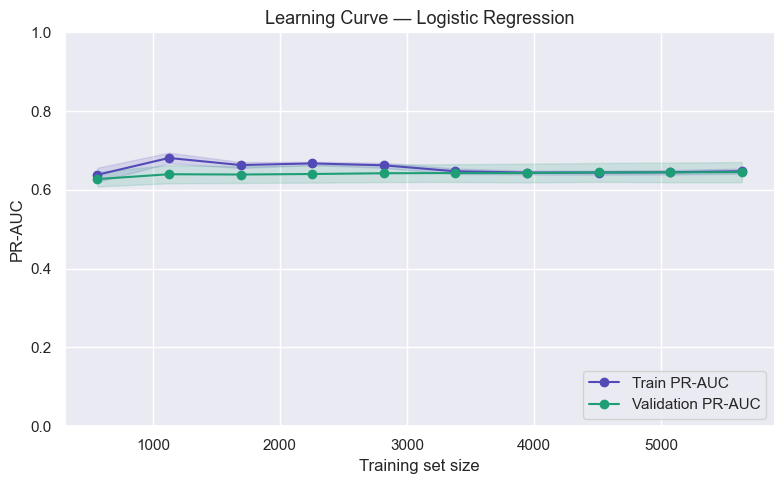

In [16]:
results_logistic_regression = train_logistic_regression_churn(df.drop('Churn', axis=1), df['Churn'])

In [17]:
results_logistic_regression["feature_importance"]

,feature,importance
0,tenure,2.142454
1,Contract_Two year,1.424221
2,InternetService_Fiber optic,1.014040
3,Contract_One year,0.722647
4,MonthlyCharges,0.593349
5,StreamingMovies_Yes,0.375830
6,StreamingTV_Yes,0.356791
7,PaymentMethod_Electronic check,0.348287
8,OnlineSecurity_Yes,0.332106
9,PaperlessBilling,0.321090


# 4. RandomForestClassifier

In [18]:
def train_random_forest_churn(
    X: pd.DataFrame,
    y: pd.Series,
    n_splits: int = 5,
    random_state: int = 42,
    **kwargs
    ) -> dict:
    """Trains a Random Forest model for churn prediction using stratified k-fold CV.

    Uses StratifiedKFold to preserve the churn rate across folds and
    class_weight='balanced_subsample' to handle class imbalance without resampling.
    One-hot encoding is applied inside the CV loop using OneHotEncoder fitted only
    on the training fold, preventing data leakage from unseen categories.
    Random Forest does not require feature scaling since it is a tree-based model
    that splits on feature thresholds. Feature importance is derived from mean
    impurity decrease (Gini) averaged across all folds.

    Args:
        X: Feature matrix. May contain both numeric and categorical (object/category)
            columns — encoding is handled internally.
        y: Binary target series. 1 = churned, 0 = retained.
        n_splits: Number of folds for StratifiedKFold cross-validation. Defaults to 5.
        random_state: Random seed for reproducibility. Defaults to 42.
        **kwargs: Additional keyword arguments passed to the Random Forest classifier.

    Returns:
        A dict with the following keys:
            - "train_metrics" (pd.DataFrame): Per-fold scores on the training fold.
            - "val_metrics" (pd.DataFrame): Per-fold scores on the validation fold.
            - "train_mean" (pd.Series): Mean of each train metric across all folds.
            - "val_mean" (pd.Series): Mean of each val metric across all folds.
            - "train_std" (pd.Series): Std of each train metric across all folds.
            - "val_std" (pd.Series): Std of each val metric across all folds.
            - "models" (list[RandomForestClassifier]): Fitted model from each fold.
            - "encoders" (list[OneHotEncoder]): Fitted encoder from each fold.
            - "feature_names" (list[str]): Feature names after encoding (from last fold).
            - "feature_importance" (pd.DataFrame): Mean Gini importance per feature
              across all folds, sorted descending.
            - "learning_curve" (dict): Contains "train_sizes", "train_scores",
              and "val_scores" arrays used to plot the learning curve.

    Raises:
        ValueError: If X and y have different numbers of rows.
        ValueError: If y contains values other than 0 and 1.

    Example:
        >>> result = train_random_forest_churn(X_raw, y, n_splits=5)
        >>> print(result["val_mean"])
        >>> print(result["feature_importance"].head(10))
    """
    # ── Input validation ───────────────────────────────────────────────────────

    if len(X) != len(y):
        raise ValueError(
            f"X and y must have the same number of rows. "
            f"Got X={len(X)}, y={len(y)}."
        )

    unique_values = set(y.unique())
    if not unique_values.issubset({0, 1}):
        raise ValueError(
            f"y must contain only binary values (0 and 1). "
            f"Got: {unique_values}."
        )

    # ── Identify column types ──────────────────────────────────────────────────

    categorical_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
    numeric_cols     = X.select_dtypes(exclude=["object", "category"]).columns.tolist()

    # ── Cross-validation setup ─────────────────────────────────────────────────

    # StratifiedKFold preserves the churn rate in each fold,
    # which is critical for imbalanced targets.
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    # Storage for per-fold results — tracked separately for train and val
    train_fold_metrics = []
    val_fold_metrics   = []
    models            = []
    encoders          = []
    importance_matrix = []
    feature_names     = []

    # ── Training loop ──────────────────────────────────────────────────────────

    for fold, (train_idx, val_idx) in enumerate(cv.split(X, y), start=1):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

        # ── One-hot encoding — fit only on training fold ───────────────────────
        # Fitting the encoder on the full dataset would leak validation category
        # frequencies into the training process. handle_unknown="ignore" silently
        # zeros out any category in the validation fold not seen during training.
        if categorical_cols:
            encoder = OneHotEncoder(
                drop="first",              # avoid multicollinearity (k-1 dummies)
                sparse_output=False,
                handle_unknown="ignore",   # unseen categories become all-zero rows
            )
            X_train_cat = encoder.fit_transform(X_train[categorical_cols])
            X_val_cat   = encoder.transform(X_val[categorical_cols])

            ohe_feature_names = encoder.get_feature_names_out(categorical_cols).tolist()

            X_train_encoded = np.hstack([X_train[numeric_cols].values, X_train_cat])
            X_val_encoded   = np.hstack([X_val[numeric_cols].values,   X_val_cat])
            fold_feature_names = numeric_cols + ohe_feature_names
        else:
            # No categorical columns — pass through unchanged
            encoder            = None
            X_train_encoded    = X_train[numeric_cols].values
            X_val_encoded      = X_val[numeric_cols].values
            fold_feature_names = numeric_cols

        # No scaling needed — Random Forest splits on thresholds,
        # so feature magnitude does not affect the model.
        model = RandomForestClassifier(
            # balanced_subsample recomputes class weights for each bootstrap sample,
            # which is more robust than balanced for ensemble methods.
            class_weight="balanced_subsample",
            n_jobs=-1,
            random_state=random_state,
            **kwargs
        )
        model.fit(X_train_encoded, y_train)

        # ── Evaluation — train fold ────────────────────────────────────────────

        train_proba = model.predict_proba(X_train_encoded)[:, 1]
        train_pred  = model.predict(X_train_encoded)

        train_fold_metrics.append({
            "fold":      fold,
            "pr_auc":    average_precision_score(y_train, train_proba),
            "roc_auc":   roc_auc_score(y_train, train_proba),
            "precision": precision_score(y_train, train_pred, zero_division=0),
            "recall":    recall_score(y_train, train_pred, zero_division=0),
            "f1":        f1_score(y_train, train_pred, zero_division=0),
        })

        # ── Evaluation — validation fold ──────────────────────────────────────

        val_proba = model.predict_proba(X_val_encoded)[:, 1]
        val_pred  = model.predict(X_val_encoded)

        # PR-AUC is the primary metric for imbalanced churn datasets
        val_fold_metrics.append({
            "fold":      fold,
            "pr_auc":    average_precision_score(y_val, val_proba),
            "roc_auc":   roc_auc_score(y_val, val_proba),
            "precision": precision_score(y_val, val_pred, zero_division=0),
            "recall":    recall_score(y_val, val_pred, zero_division=0),
            "f1":        f1_score(y_val, val_pred, zero_division=0),
        })

        models.append(model)
        encoders.append(encoder)
        feature_names = fold_feature_names

        # Gini-based feature importance from the fitted forest
        importance_matrix.append(model.feature_importances_)

        # Print detailed fold metrics
        print(f"\nFold {fold}/{n_splits}:")
        print(f"  Train — PR-AUC: {train_fold_metrics[-1]['pr_auc']:.4f},\
               ROC-AUC: {train_fold_metrics[-1]['roc_auc']:.4f},\
                Recall: {train_fold_metrics[-1]['recall']:.4f}, Precision: {train_fold_metrics[-1]['precision']:.4f},\
                     F1: {train_fold_metrics[-1]['f1']:.4f}")
        print(f"  Val   — PR-AUC: {val_fold_metrics[-1]['pr_auc']:.4f},\
               ROC-AUC: {val_fold_metrics[-1]['roc_auc']:.4f},\
                Recall: {val_fold_metrics[-1]['recall']:.4f}, Precision: {val_fold_metrics[-1]['precision']:.4f},\
                     F1: {val_fold_metrics[-1]['f1']:.4f}")

    # ── Aggregate results ──────────────────────────────────────────────────────

    train_metrics_df = pd.DataFrame(train_fold_metrics).set_index("fold")
    val_metrics_df   = pd.DataFrame(val_fold_metrics).set_index("fold")

    train_mean = train_metrics_df.mean()
    train_std  = train_metrics_df.std()
    val_mean   = val_metrics_df.mean()
    val_std    = val_metrics_df.std()

    print("\n── Cross-validation summary ──────────────────────────")
    print(f"{'metric':>10} {'train mean':>12} {'train std':>10} {'val mean':>10} {'val std':>10}")
    print("-" * 56)
    for metric in val_metrics_df.columns:
        print(
            f"{metric:>10} "
            f"{train_mean[metric]:>12.4f} "
            f"{train_std[metric]:>10.4f} "
            f"{val_mean[metric]:>10.4f} "
            f"{val_std[metric]:>10.4f}"
        )

    # ── Feature importance ─────────────────────────────────────────────────────

    # Average Gini importance across folds reduces the variance
    # inherent to single-fold estimates.
    mean_importance = np.mean(importance_matrix, axis=0)
    feature_importance = (
        pd.DataFrame({
            "feature":    feature_names,
            "importance": mean_importance,
        })
        .sort_values("importance", ascending=False)
        .reset_index(drop=True)
    )

    # ── Learning curve ─────────────────────────────────────────────────────────

    # ColumnTransformer handles encoding inside the pipeline so learning_curve
    # applies OHE correctly at each training subset without leakage.
    # No scaling step needed — Random Forest does not require it.
    preprocessor = ColumnTransformer([
        ("num", "passthrough", numeric_cols),
        ("cat", OneHotEncoder(drop="first", sparse_output=False,
                              handle_unknown="ignore"), categorical_cols),
    ]) if categorical_cols else ColumnTransformer([
        ("num", "passthrough", numeric_cols),
    ])

    lc_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("clf", RandomForestClassifier(
            class_weight="balanced_subsample",
            n_jobs=-1,
            random_state=random_state,
            **kwargs
        )),
    ])

    train_sizes, train_scores, val_scores = learning_curve(
        estimator=lc_pipeline,
        X=X,
        y=y,
        cv=StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state),
        scoring="average_precision",   # PR-AUC — consistent with primary metric
        train_sizes=np.linspace(0.1, 1.0, 10),
        n_jobs=-1,
    )

    plot_learning_curve(
        train_sizes=train_sizes,
        train_scores=train_scores,
        val_scores=val_scores,
        title="Learning Curve — Random Forest",
    )

    return {
        "train_metrics":      train_metrics_df,
        "val_metrics":        val_metrics_df,
        "train_mean":         train_mean,
        "val_mean":           val_mean,
        "train_std":          train_std,
        "val_std":            val_std,
        "models":             models,
        "encoders":           encoders,
        "feature_names":      feature_names,
        "feature_importance": feature_importance,
        "learning_curve": {
            "train_sizes":  train_sizes,
            "train_scores": train_scores,
            "val_scores":   val_scores,
        },
    }


Fold 1/5:
  Train — PR-AUC: 0.7045,               ROC-AUC: 0.8718,                Recall: 0.8120, Precision: 0.5538,                     F1: 0.6585
  Val   — PR-AUC: 0.6723,               ROC-AUC: 0.8599,                Recall: 0.7968, Precision: 0.5549,                     F1: 0.6542

Fold 2/5:
  Train — PR-AUC: 0.7134,               ROC-AUC: 0.8761,                Recall: 0.8214, Precision: 0.5638,                     F1: 0.6687
  Val   — PR-AUC: 0.6438,               ROC-AUC: 0.8426,                Recall: 0.7888, Precision: 0.5212,                     F1: 0.6277

Fold 3/5:
  Train — PR-AUC: 0.7026,               ROC-AUC: 0.8723,                Recall: 0.8167, Precision: 0.5573,                     F1: 0.6625
  Val   — PR-AUC: 0.6884,               ROC-AUC: 0.8579,                Recall: 0.7968, Precision: 0.5408,                     F1: 0.6443

Fold 4/5:
  Train — PR-AUC: 0.7216,               ROC-AUC: 0.8790,                Recall: 0.8175, Precision: 0.5644,                     F

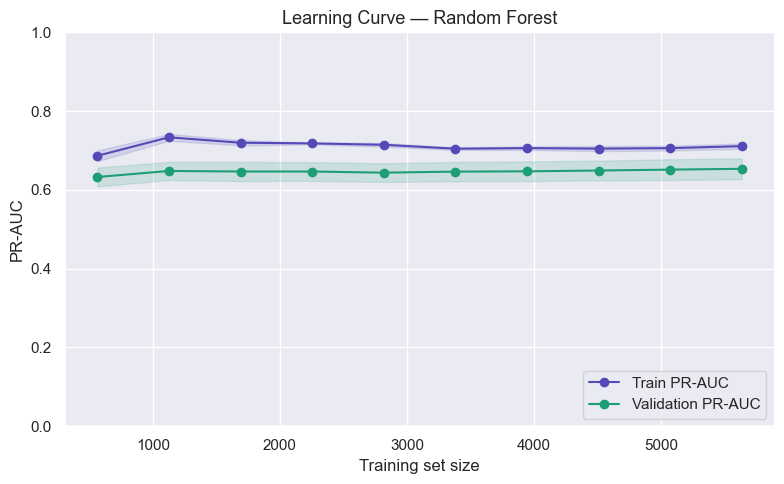

In [19]:
results_random_forest = train_random_forest_churn(
    df.drop('Churn', axis=1),
    df['Churn'],
    n_estimators=300,
    min_samples_leaf=20,
    max_features='sqrt',
    max_depth=None
)

In [21]:
results_random_forest['feature_importance']

,feature,importance
0,tenure,0.253955
1,Contract_Two year,0.145008
2,InternetService_Fiber optic,0.104180
3,MonthlyCharges,0.078540
4,PaymentMethod_Electronic check,0.071866
5,Contract_One year,0.056102
6,OnlineSecurity_Yes,0.041154
7,TechSupport_Yes,0.037294
8,StreamingMovies_No internet service,0.024031
9,OnlineBackup_No internet service,0.019797


# 5. LGBM

In [22]:
def train_lightgbm_churn(
    X: pd.DataFrame,
    y: pd.Series,
    n_splits: int = 5,
    random_state: int = 42,
    **kwargs
) -> dict:
    """Trains a LightGBM model for churn prediction using stratified k-fold CV.

    Uses StratifiedKFold to preserve the churn rate across folds and
    scale_pos_weight to handle class imbalance without resampling. One-hot
    encoding is applied inside the CV loop using OneHotEncoder fitted only on
    the training fold, preventing data leakage from unseen categories. LightGBM
    does not require feature scaling. Early stopping is applied on PR-AUC
    evaluated on the validation fold to prevent overfitting and reduce training
    time. Feature importance is reported both as split count and gain, averaged
    across all folds.

    Args:
        X: Feature matrix. May contain both numeric and categorical (object/category)
            columns — encoding is handled internally.
        y: Binary target series. 1 = churned, 0 = retained.
        n_splits: Number of folds for StratifiedKFold cross-validation. Defaults to 5.
        random_state: Random seed for reproducibility. Defaults to 42.
        **kwargs: Additional keyword arguments passed to the LightGBM classifier.

    Returns:
        A dict with the following keys:
            - "train_metrics" (pd.DataFrame): Per-fold scores on the training fold.
            - "val_metrics" (pd.DataFrame): Per-fold scores on the validation fold.
            - "train_mean" (pd.Series): Mean of each train metric across all folds.
            - "val_mean" (pd.Series): Mean of each val metric across all folds.
            - "train_std" (pd.Series): Std of each train metric across all folds.
            - "val_std" (pd.Series): Std of each val metric across all folds.
            - "models" (list[lgb.Booster]): Fitted booster from each fold.
            - "encoders" (list[OneHotEncoder]): Fitted encoder from each fold.
            - "feature_names" (list[str]): Feature names after encoding (from last fold).
            - "feature_importance_split" (pd.DataFrame): Mean split-count importance
              per feature across all folds, sorted descending.
            - "feature_importance_gain" (pd.DataFrame): Mean gain importance per
              feature across all folds, sorted descending.
            - "learning_curve" (dict): Contains "train_sizes", "train_scores",
              and "val_scores" arrays used to plot the learning curve.

    Raises:
        ValueError: If X and y have different numbers of rows.
        ValueError: If y contains values other than 0 and 1.

    Example:
        >>> result = train_lightgbm_churn(X_raw, y, n_splits=5)
        >>> print(result["val_mean"])
        >>> print(result["feature_importance_gain"].head(10))
    """
    # ── Input validation ───────────────────────────────────────────────────────

    if len(X) != len(y):
        raise ValueError(
            f"X and y must have the same number of rows. "
            f"Got X={len(X)}, y={len(y)}."
        )

    unique_values = set(y.unique())
    if not unique_values.issubset({0, 1}):
        raise ValueError(
            f"y must contain only binary values (0 and 1). "
            f"Got: {unique_values}."
        )

    # ── Identify column types ──────────────────────────────────────────────────

    categorical_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
    numeric_cols     = X.select_dtypes(exclude=["object", "category"]).columns.tolist()

    # ── Cross-validation setup ─────────────────────────────────────────────────

    # StratifiedKFold preserves the churn rate in each fold,
    # which is critical for imbalanced targets.
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    # scale_pos_weight balances the gradient contribution of the minority class
    # (churners) relative to the majority class (retained customers).
    scale_pos_weight = (y == 0).sum() / (y == 1).sum()

    # Storage for per-fold results — tracked separately for train and val
    train_fold_metrics      = []
    val_fold_metrics        = []
    models                  = []
    encoders                = []
    importance_split_matrix = []
    importance_gain_matrix  = []
    feature_names           = []

    # ── Training loop ──────────────────────────────────────────────────────────

    for fold, (train_idx, val_idx) in enumerate(cv.split(X, y), start=1):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

        # ── One-hot encoding — fit only on training fold ───────────────────────
        # Fitting the encoder on the full dataset would leak validation category
        # frequencies into the training process. handle_unknown="ignore" silently
        # zeros out any category in the validation fold not seen during training.
        if categorical_cols:
            encoder = OneHotEncoder(
                drop="first",              # avoid multicollinearity (k-1 dummies)
                sparse_output=False,
                handle_unknown="ignore",   # unseen categories become all-zero rows
            )
            X_train_cat = encoder.fit_transform(X_train[categorical_cols])
            X_val_cat   = encoder.transform(X_val[categorical_cols])

            ohe_feature_names = encoder.get_feature_names_out(categorical_cols).tolist()

            X_train_encoded = np.hstack([X_train[numeric_cols].values, X_train_cat])
            X_val_encoded   = np.hstack([X_val[numeric_cols].values,   X_val_cat])
            fold_feature_names = numeric_cols + ohe_feature_names
        else:
            # No categorical columns — pass through unchanged
            encoder            = None
            X_train_encoded    = X_train[numeric_cols].values
            X_val_encoded      = X_val[numeric_cols].values
            fold_feature_names = numeric_cols

        # LightGBM native Dataset format — more memory efficient than numpy arrays
        dtrain = lgb.Dataset(X_train_encoded, label=y_train,
                             feature_name=fold_feature_names)
        dval   = lgb.Dataset(X_val_encoded,   label=y_val,
                             feature_name=fold_feature_names, reference=dtrain)

        params = {
            "objective":        "binary",
            "metric":           "average_precision",  # PR-AUC as early stopping metric
            "verbosity":        -1,                   # suppress LightGBM training logs
            "n_jobs":           -1,
            "scale_pos_weight": scale_pos_weight,
            **kwargs
        }

        callbacks = [
            lgb.early_stopping(stopping_rounds=50, verbose=False),
            lgb.log_evaluation(period=-1),
        ]

        model = lgb.train(
            params,
            dtrain,
            valid_sets=[dval],
            callbacks=callbacks,
        )

        # ── Evaluation — train fold ────────────────────────────────────────────

        train_proba = model.predict(X_train_encoded)
        train_pred  = (train_proba >= 0.5).astype(int)

        train_fold_metrics.append({
            "fold":           fold,
            "pr_auc":         average_precision_score(y_train, train_proba),
            "roc_auc":        roc_auc_score(y_train, train_proba),
            "precision":      precision_score(y_train, train_pred, zero_division=0),
            "recall":         recall_score(y_train, train_pred, zero_division=0),
            "f1":             f1_score(y_train, train_pred, zero_division=0),
            "best_iteration": model.best_iteration,
        })

        # ── Evaluation — validation fold ──────────────────────────────────────

        val_proba = model.predict(X_val_encoded)

        # Default threshold of 0.5 for precision/recall/f1 —
        # threshold should be optimized separately via cost function.
        val_pred = (val_proba >= 0.5).astype(int)

        # PR-AUC is the primary metric for imbalanced churn datasets
        val_fold_metrics.append({
            "fold":           fold,
            "pr_auc":         average_precision_score(y_val, val_proba),
            "roc_auc":        roc_auc_score(y_val, val_proba),
            "precision":      precision_score(y_val, val_pred, zero_division=0),
            "recall":         recall_score(y_val, val_pred, zero_division=0),
            "f1":             f1_score(y_val, val_pred, zero_division=0),
            "best_iteration": model.best_iteration,
        })

        models.append(model)
        encoders.append(encoder)
        feature_names = fold_feature_names

        # LightGBM provides two importance types:
        # - split: number of times a feature is used to split a node
        # - gain: total reduction in loss from splits using the feature (more reliable)
        importance_split_matrix.append(
            model.feature_importance(importance_type="split")
        )
        importance_gain_matrix.append(
            model.feature_importance(importance_type="gain")
        )

        # Print full per-fold train and validation metrics
        print(f"Full metrics for fold {fold}:")
        print("  Train metrics:")
        for k, v in train_fold_metrics[-1].items():
            if k != "fold":
                print(f"    {k}: {v}")
        print("  Validation metrics:")
        for k, v in val_fold_metrics[-1].items():
            if k != "fold":
                print(f"    {k}: {v}")

    # ── Aggregate results ──────────────────────────────────────────────────────

    train_metrics_df = pd.DataFrame(train_fold_metrics).set_index("fold")
    val_metrics_df   = pd.DataFrame(val_fold_metrics).set_index("fold")

    train_mean = train_metrics_df.mean()
    train_std  = train_metrics_df.std()
    val_mean   = val_metrics_df.mean()
    val_std    = val_metrics_df.std()

    print("\n── Cross-validation summary ──────────────────────────")
    print(f"{'metric':>16} {'train mean':>12} {'train std':>10} {'val mean':>10} {'val std':>10}")
    print("-" * 62)
    for metric in val_metrics_df.columns:
        print(
            f"{metric:>16} "
            f"{train_mean[metric]:>12.4f} "
            f"{train_std[metric]:>10.4f} "
            f"{val_mean[metric]:>10.4f} "
            f"{val_std[metric]:>10.4f}"
        )

    # ── Feature importance ─────────────────────────────────────────────────────

    # Average importance across folds to reduce single-fold variance.
    # Gain importance is generally more informative than split count.
    def _build_importance_df(matrix: list[np.ndarray]) -> pd.DataFrame:
        return (
            pd.DataFrame({
                "feature":    feature_names,
                "importance": np.mean(matrix, axis=0),
            })
            .sort_values("importance", ascending=False)
            .reset_index(drop=True)
        )

    # ── Learning curve ─────────────────────────────────────────────────────────

    # ColumnTransformer handles encoding inside the pipeline so learning_curve
    # applies OHE correctly at each training subset without leakage.
    # LGBMClassifier wraps lgb.train in the sklearn API for compatibility.
    best_iter = max(1, int(np.mean([m.best_iteration for m in models])))

    preprocessor = ColumnTransformer([
        ("num", "passthrough", numeric_cols),
        ("cat", OneHotEncoder(drop="first", sparse_output=False,
                              handle_unknown="ignore"), categorical_cols),
    ]) if categorical_cols else ColumnTransformer([
        ("num", "passthrough", numeric_cols),
    ])

    lc_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("clf", lgb.LGBMClassifier(
            n_estimators=best_iter,
            scale_pos_weight=scale_pos_weight,
            random_state=random_state,
            verbosity=-1,
            n_jobs=-1,
        )),
    ])

    train_sizes, train_scores, val_scores = learning_curve(
        estimator=lc_pipeline,
        X=X,
        y=y,
        cv=StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state),
        scoring="average_precision",   # PR-AUC — consistent with primary metric
        train_sizes=np.linspace(0.1, 1.0, 10),
        n_jobs=-1,
    )

    plot_learning_curve(
        train_sizes=train_sizes,
        train_scores=train_scores,
        val_scores=val_scores,
        title="Learning Curve — LightGBM",
    )

    return {
        "train_metrics":             train_metrics_df,
        "val_metrics":               val_metrics_df,
        "train_mean":                train_mean,
        "val_mean":                  val_mean,
        "train_std":                 train_std,
        "val_std":                   val_std,
        "models":                    models,
        "encoders":                  encoders,
        "feature_names":             feature_names,
        "feature_importance_split":  _build_importance_df(importance_split_matrix),
        "feature_importance_gain":   _build_importance_df(importance_gain_matrix),
        "learning_curve": {
            "train_sizes":  train_sizes,
            "train_scores": train_scores,
            "val_scores":   val_scores,
        },
    }

Full metrics for fold 1:
  Train metrics:
    pr_auc: 0.7845358210792205
    roc_auc: 0.9170537048274792
    precision: 0.5996384997740624
    recall: 0.8876254180602007
    f1: 0.7157497303128371
    best_iteration: 68
  Validation metrics:
    pr_auc: 0.6751999350862412
    roc_auc: 0.8538905680849415
    precision: 0.5451197053406999
    recall: 0.7914438502673797
    f1: 0.6455834242093784
    best_iteration: 68
Full metrics for fold 2:
  Train metrics:
    pr_auc: 0.7277273130254237
    roc_auc: 0.8931840127476545
    precision: 0.5741155396327811
    recall: 0.8575250836120402
    f1: 0.6877682403433476
    best_iteration: 30
  Validation metrics:
    pr_auc: 0.6472148581555951
    roc_auc: 0.8360239220853032
    precision: 0.5180505415162455
    recall: 0.767379679144385
    f1: 0.6185344827586207
    best_iteration: 30
Full metrics for fold 3:
  Train metrics:
    pr_auc: 0.7679651582112366
    roc_auc: 0.9112696667073379
    precision: 0.5964593735814798
    recall: 0.87892976

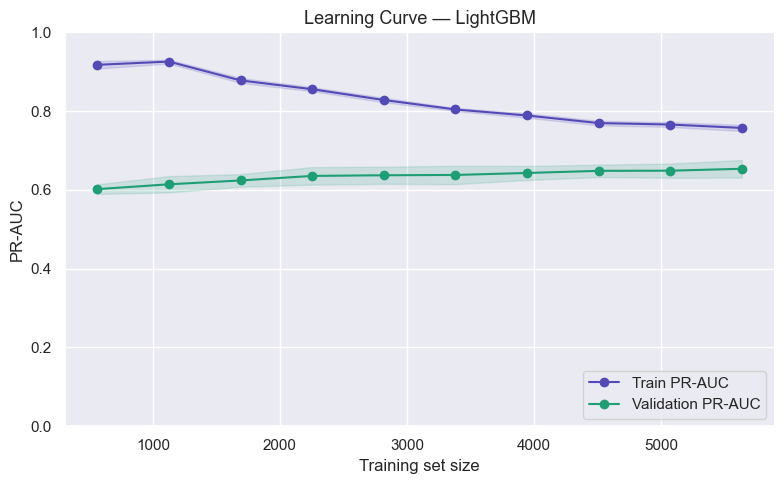

In [24]:
results_lgbm = train_lightgbm_churn(df.drop('Churn', axis=1), df['Churn'])

In [25]:
results_lgbm['feature_importance_gain']

,feature,importance
0,Contract_Two year,7573.275580
1,tenure,4585.316551
2,Contract_One year,3899.618905
3,MonthlyCharges,3686.282789
4,InternetService_Fiber optic,1599.142419
5,StreamingMovies_Yes,780.438626
6,PaymentMethod_Electronic check,735.917947
7,PaperlessBilling,428.937967
8,InternetService_No,375.037869
9,OnlineSecurity_Yes,362.504765


# 6. XGBoost

In [26]:
def train_xgboost_churn(
    X: pd.DataFrame,
    y: pd.Series,
    n_splits: int = 5,
    random_state: int = 42,
    **kwargs
) -> dict:
    """Trains an XGBoost model for churn prediction using stratified k-fold CV.

    Uses StratifiedKFold to preserve the churn rate across folds and
    scale_pos_weight to handle class imbalance without resampling. One-hot
    encoding is applied inside the CV loop using OneHotEncoder fitted only on
    the training fold, preventing data leakage from unseen categories. XGBoost
    does not require feature scaling. Early stopping is applied on PR-AUC
    evaluated on the validation fold to prevent overfitting and reduce training
    time. Feature importance is reported both as weight (split count) and gain,
    averaged across all folds.

    Args:
        X: Feature matrix. May contain both numeric and categorical (object/category)
            columns — encoding is handled internally.
        y: Binary target series. 1 = churned, 0 = retained.
        n_splits: Number of folds for StratifiedKFold cross-validation. Defaults to 5.
        random_state: Random seed for reproducibility. Defaults to 42.
        **kwargs: Additional keyword arguments passed to the XGBoost classifier.

    Returns:
        A dict with the following keys:
            - "train_metrics" (pd.DataFrame): Per-fold scores on the training fold.
            - "val_metrics" (pd.DataFrame): Per-fold scores on the validation fold.
            - "train_mean" (pd.Series): Mean of each train metric across all folds.
            - "val_mean" (pd.Series): Mean of each val metric across all folds.
            - "train_std" (pd.Series): Std of each train metric across all folds.
            - "val_std" (pd.Series): Std of each val metric across all folds.
            - "models" (list[xgb.Booster]): Fitted booster from each fold.
            - "encoders" (list[OneHotEncoder]): Fitted encoder from each fold.
            - "feature_names" (list[str]): Feature names after encoding (from last fold).
            - "feature_importance_weight" (pd.DataFrame): Mean split-count importance
              per feature across all folds, sorted descending.
            - "feature_importance_gain" (pd.DataFrame): Mean gain importance per
              feature across all folds, sorted descending.
            - "learning_curve" (dict): Contains "train_sizes", "train_scores",
              and "val_scores" arrays used to plot the learning curve.

    Raises:
        ValueError: If X and y have different numbers of rows.
        ValueError: If y contains values other than 0 and 1.

    Example:
        >>> result = train_xgboost_churn(X_raw, y, n_splits=5)
        >>> print(result["val_mean"])
        >>> print(result["feature_importance_gain"].head(10))
    """
    # ── Input validation ───────────────────────────────────────────────────────

    if len(X) != len(y):
        raise ValueError(
            f"X and y must have the same number of rows. "
            f"Got X={len(X)}, y={len(y)}."
        )

    unique_values = set(y.unique())
    if not unique_values.issubset({0, 1}):
        raise ValueError(
            f"y must contain only binary values (0 and 1). "
            f"Got: {unique_values}."
        )

    # ── Identify column types ──────────────────────────────────────────────────

    categorical_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
    numeric_cols     = X.select_dtypes(exclude=["object", "category"]).columns.tolist()

    # ── Cross-validation setup ─────────────────────────────────────────────────

    # StratifiedKFold preserves the churn rate in each fold,
    # which is critical for imbalanced targets.
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    # scale_pos_weight balances the gradient contribution of the minority class
    # (churners) relative to the majority class (retained customers).
    scale_pos_weight = (y == 0).sum() / (y == 1).sum()

    # Storage for per-fold results — tracked separately for train and val
    train_fold_metrics       = []
    val_fold_metrics         = []
    models                   = []
    encoders                 = []
    importance_weight_matrix = []
    importance_gain_matrix   = []
    feature_names            = []

    # ── Training loop ──────────────────────────────────────────────────────────

    for fold, (train_idx, val_idx) in enumerate(cv.split(X, y), start=1):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

        # ── One-hot encoding — fit only on training fold ───────────────────────
        # Fitting the encoder on the full dataset would leak validation category
        # frequencies into the training process. handle_unknown="ignore" silently
        # zeros out any category in the validation fold not seen during training.
        if categorical_cols:
            encoder = OneHotEncoder(
                drop="first",              # avoid multicollinearity (k-1 dummies)
                sparse_output=False,
                handle_unknown="ignore",   # unseen categories become all-zero rows
            )
            X_train_cat = encoder.fit_transform(X_train[categorical_cols])
            X_val_cat   = encoder.transform(X_val[categorical_cols])

            ohe_feature_names = encoder.get_feature_names_out(categorical_cols).tolist()

            X_train_encoded = np.hstack([X_train[numeric_cols].values, X_train_cat])
            X_val_encoded   = np.hstack([X_val[numeric_cols].values,   X_val_cat])
            fold_feature_names = numeric_cols + ohe_feature_names
        else:
            # No categorical columns — pass through unchanged
            encoder            = None
            X_train_encoded    = X_train[numeric_cols].values
            X_val_encoded      = X_val[numeric_cols].values
            fold_feature_names = numeric_cols

        # XGBoost native DMatrix format — more memory efficient than numpy arrays.
        # feature_names uses the post-encoding names so importance dicts are readable.
        dtrain = xgb.DMatrix(X_train_encoded, label=y_train,
                             feature_names=fold_feature_names)
        dval   = xgb.DMatrix(X_val_encoded,   label=y_val,
                             feature_names=fold_feature_names)

        params = {
            "objective":        "binary:logistic",
            "eval_metric":      "aucpr",          # PR-AUC as early stopping metric
            "seed":             random_state,
            "verbosity":        0,                # suppress XGBoost training logs
            "scale_pos_weight": scale_pos_weight,
            "nthread":          -1,
            **kwargs
        }

        # evals_result stores per-round metric history — useful for diagnostics
        evals_result: dict = {}

        model = xgb.train(
            params,
            dtrain,
            evals=[(dtrain, "train"), (dval, "val")],
            evals_result=evals_result,
            verbose_eval=False,
            early_stopping_rounds=50,
        )

        # ── Evaluation — train fold ────────────────────────────────────────────

        train_proba = model.predict(dtrain)
        train_pred  = (train_proba >= 0.5).astype(int)

        train_fold_metrics.append({
            "fold":           fold,
            "pr_auc":         average_precision_score(y_train, train_proba),
            "roc_auc":        roc_auc_score(y_train, train_proba),
            "precision":      precision_score(y_train, train_pred, zero_division=0),
            "recall":         recall_score(y_train, train_pred, zero_division=0),
            "f1":             f1_score(y_train, train_pred, zero_division=0),
            "best_iteration": model.best_iteration,
        })

        # ── Evaluation — validation fold ──────────────────────────────────────

        val_proba = model.predict(dval)

        # Default threshold of 0.5 for precision/recall/f1 —
        # threshold should be optimized separately via cost function.
        val_pred = (val_proba >= 0.5).astype(int)

        # PR-AUC is the primary metric for imbalanced churn datasets
        val_fold_metrics.append({
            "fold":           fold,
            "pr_auc":         average_precision_score(y_val, val_proba),
            "roc_auc":        roc_auc_score(y_val, val_proba),
            "precision":      precision_score(y_val, val_pred, zero_division=0),
            "recall":         recall_score(y_val, val_pred, zero_division=0),
            "f1":             f1_score(y_val, val_pred, zero_division=0),
            "best_iteration": model.best_iteration,
        })

        models.append(model)
        encoders.append(encoder)
        feature_names = fold_feature_names

        # XGBoost provides two importance types:
        # - weight: number of times a feature is used to split a node
        # - gain: average gain across all splits that use the feature (more reliable)
        # get_score returns a dict keyed by feature name — use fold_feature_names
        # to ensure all features appear even if some were never used for a split.
        importance_weight_matrix.append(
            np.array([
                model.get_score(importance_type="weight").get(f, 0)
                for f in fold_feature_names
            ])
        )
        importance_gain_matrix.append(
            np.array([
                model.get_score(importance_type="gain").get(f, 0)
                for f in fold_feature_names
            ])
        )

        train_metrics = train_fold_metrics[-1]
        val_metrics   = val_fold_metrics[-1]

        print(
            f"  Train metrics: PR-AUC={train_metrics['pr_auc']:.4f},\n"
            f"ROC-AUC={train_metrics['roc_auc']:.4f},\n"
            f"Precision={train_metrics['precision']:.4f},\n "
            f"Recall={train_metrics['recall']:.4f},\n "
            f"F1={train_metrics['f1']:.4f},\n "
            f"Best iter={train_metrics['best_iteration']}\n"
        )
        print(
            f"  Validation metrics: PR-AUC={val_metrics['pr_auc']:.4f},\n "
            f"ROC-AUC={val_metrics['roc_auc']:.4f},\n "
            f"Precision={val_metrics['precision']:.4f},\n "
            f"Recall={val_metrics['recall']:.4f},\n "
            f"F1={val_metrics['f1']:.4f},\n "
            f"Best iter={val_metrics['best_iteration']}\n"
        )

    # ── Aggregate results ──────────────────────────────────────────────────────

    train_metrics_df = pd.DataFrame(train_fold_metrics).set_index("fold")
    val_metrics_df   = pd.DataFrame(val_fold_metrics).set_index("fold")

    train_mean = train_metrics_df.mean()
    train_std  = train_metrics_df.std()
    val_mean   = val_metrics_df.mean()
    val_std    = val_metrics_df.std()

    print("\n── Cross-validation summary ──────────────────────────")
    print(f"{'metric':>16} {'train mean':>12} {'train std':>10} {'val mean':>10} {'val std':>10}")
    print("-" * 62)
    for metric in val_metrics_df.columns:
        print(
            f"{metric:>16} "
            f"{train_mean[metric]:>12.4f} "
            f"{train_std[metric]:>10.4f} "
            f"{val_mean[metric]:>10.4f} "
            f"{val_std[metric]:>10.4f}"
        )

    # ── Feature importance ─────────────────────────────────────────────────────

    # Average importance across folds to reduce single-fold variance.
    # Gain importance is generally more informative than weight count.
    def _build_importance_df(matrix: list[np.ndarray]) -> pd.DataFrame:
        return (
            pd.DataFrame({
                "feature":    feature_names,
                "importance": np.mean(matrix, axis=0),
            })
            .sort_values("importance", ascending=False)
            .reset_index(drop=True)
        )

    # ── Learning curve ─────────────────────────────────────────────────────────

    # ColumnTransformer handles encoding inside the pipeline so learning_curve
    # applies OHE correctly at each training subset without leakage.
    # early_stopping_rounds is intentionally omitted from XGBClassifier here —
    # learning_curve does not provide eval_set, which XGBoost requires for
    # early stopping. n_estimators is fixed to mean best_iteration from CV.
    best_iter = max(1, int(np.mean([m.best_iteration for m in models])))

    preprocessor = ColumnTransformer([
        ("num", "passthrough", numeric_cols),
        ("cat", OneHotEncoder(drop="first", sparse_output=False,
                              handle_unknown="ignore"), categorical_cols),
    ]) if categorical_cols else ColumnTransformer([
        ("num", "passthrough", numeric_cols),
    ])

    if kwargs.get("n_estimators") is not None:
        print(f"Using n_estimators={kwargs['n_estimators']} for learning curve "
              f"instead of best_iteration={best_iter}.")
        lc_clf = xgb.XGBClassifier(
            scale_pos_weight=scale_pos_weight,
            random_state=random_state,
            verbosity=0,
            n_jobs=-1,
            eval_metric="aucpr",
            **kwargs
        )
    else:
        lc_clf = xgb.XGBClassifier(
            n_estimators=best_iter,
            scale_pos_weight=scale_pos_weight,
            random_state=random_state,
            verbosity=0,
            n_jobs=-1,
            eval_metric="aucpr",
            **kwargs
        )

    lc_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("clf", lc_clf),
    ])

    train_sizes, train_scores, val_scores = learning_curve(
        estimator=lc_pipeline,
        X=X,
        y=y,
        cv=StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state),
        scoring="average_precision",   # PR-AUC — consistent with primary metric
        train_sizes=np.linspace(0.1, 1.0, 10),
        n_jobs=-1,
    )

    plot_learning_curve(
        train_sizes=train_sizes,
        train_scores=train_scores,
        val_scores=val_scores,
        title="Learning Curve — XGBoost",
    )

    return {
        "train_metrics":              train_metrics_df,
        "val_metrics":                val_metrics_df,
        "train_mean":                 train_mean,
        "val_mean":                   val_mean,
        "train_std":                  train_std,
        "val_std":                    val_std,
        "models":                     models,
        "encoders":                   encoders,
        "feature_names":              feature_names,
        "feature_importance_weight":  _build_importance_df(importance_weight_matrix),
        "feature_importance_gain":    _build_importance_df(importance_gain_matrix),
        "learning_curve": {
            "train_sizes":  train_sizes,
            "train_scores": train_scores,
            "val_scores":   val_scores,
        },
    }

  Train metrics: PR-AUC=0.7246,
ROC-AUC=0.8904,
Precision=0.5598,
 Recall=0.8642,
 F1=0.6795,
 Best iter=2

  Validation metrics: PR-AUC=0.6653,
 ROC-AUC=0.8531,
 Precision=0.5344,
 Recall=0.8102,
 F1=0.6440,
 Best iter=2

  Train metrics: PR-AUC=0.7291,
ROC-AUC=0.8904,
Precision=0.5622,
 Recall=0.8615,
 F1=0.6804,
 Best iter=9

  Validation metrics: PR-AUC=0.6406,
 ROC-AUC=0.8364,
 Precision=0.5060,
 Recall=0.7861,
 F1=0.6157,
 Best iter=9

  Train metrics: PR-AUC=0.7211,
ROC-AUC=0.8890,
Precision=0.5605,
 Recall=0.8548,
 F1=0.6771,
 Best iter=9

  Validation metrics: PR-AUC=0.6762,
 ROC-AUC=0.8471,
 Precision=0.5471,
 Recall=0.8075,
 F1=0.6523,
 Best iter=9

  Train metrics: PR-AUC=0.7336,
ROC-AUC=0.8930,
Precision=0.5570,
 Recall=0.8690,
 F1=0.6789,
 Best iter=7

  Validation metrics: PR-AUC=0.6084,
 ROC-AUC=0.8213,
 Precision=0.4932,
 Recall=0.7748,
 F1=0.6027,
 Best iter=7

  Train metrics: PR-AUC=0.7238,
ROC-AUC=0.8918,
Precision=0.5698,
 Recall=0.8622,
 F1=0.6862,
 Best iter=9



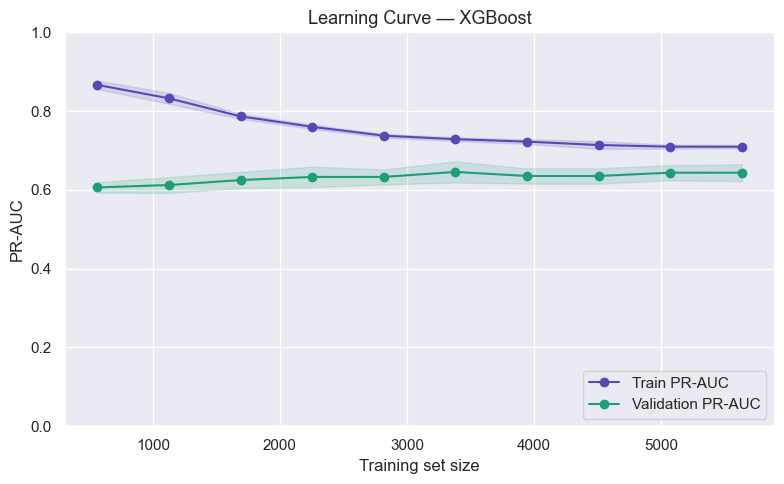

In [28]:
results_xgboost = train_xgboost_churn(df.drop('Churn', axis=1), df['Churn'])

In [49]:
results_xgboost['feature_importance_weight']

,feature,importance
0,MonthlyCharges,167.8
1,tenure,142.8
2,PaymentMethod_Electronic check,23.0
3,PaperlessBilling,21.8
4,SeniorCitizen,19.6
5,TechSupport_No,17.6
6,OnlineSecurity_No,17.6
7,OnlineBackup_No,14.8
8,Dependents,12.6
9,Contract_One year,11.4


# 7. SVC

In [30]:
def train_svm_churn(
    X: pd.DataFrame,
    y: pd.Series,
    n_splits: int = 5,
    random_state: int = 42,
    C: float = 1.0,
    kernel: str = "rbf",
    gamma: str = "scale",
    degree: int = 3,
) -> dict:
    """Trains an SVM model for churn prediction using stratified k-fold CV.

    Uses StratifiedKFold to preserve the churn rate across folds. One-hot
    encoding is applied inside the CV loop using OneHotEncoder fitted only on
    the training fold, preventing data leakage from unseen categories. The
    order within each fold is: encode → scale → fit, so that MinMaxScaler
    operates on the already-encoded numeric matrix. Probability estimates are
    enabled via Platt scaling (probability=True), which allows PR-AUC
    computation but increases training time. Because SVM does not produce
    native feature importances, the returned feature_importance key is None.

    Note:
        SVM scales poorly with large datasets (O(n²) to O(n³) in training time).
        For datasets above ~10k rows, consider using LinearSVC with
        CalibratedClassifierCV instead, or prefer LightGBM/XGBoost.

    Args:
        X: Feature matrix. May contain both numeric and categorical (object/category)
            columns — encoding is handled internally.
        y: Binary target series. 1 = churned, 0 = retained.
        n_splits: Number of folds for StratifiedKFold cross-validation. Defaults to 5.
        random_state: Random seed for reproducibility. Defaults to 42.
        C: Regularization parameter. Smaller values apply stronger regularization
            (larger margin, more misclassifications allowed). Defaults to 1.0.
        kernel: Kernel type. One of 'rbf', 'linear', 'poly', 'sigmoid'.
            'rbf' is the standard choice for non-linear churn patterns. Defaults
            to 'rbf'.
        gamma: Kernel coefficient for 'rbf', 'poly', and 'sigmoid'. 'scale' uses
            1 / (n_features * X.var()), 'auto' uses 1 / n_features. Defaults
            to 'scale'.
        degree: Degree of the polynomial kernel. Ignored by all other kernels.
            Defaults to 3.

    Returns:
        A dict with the following keys:
            - "train_metrics" (pd.DataFrame): Per-fold scores on the training fold.
            - "val_metrics" (pd.DataFrame): Per-fold scores on the validation fold.
            - "train_mean" (pd.Series): Mean of each train metric across all folds.
            - "val_mean" (pd.Series): Mean of each val metric across all folds.
            - "train_std" (pd.Series): Std of each train metric across all folds.
            - "val_std" (pd.Series): Std of each val metric across all folds.
            - "models" (list[SVC]): Fitted SVC from each fold.
            - "scalers" (list[MinMaxScaler]): Fitted scaler from each fold.
            - "encoders" (list[OneHotEncoder]): Fitted encoder from each fold.
            - "feature_names" (list[str]): Feature names after encoding (from last fold).
            - "feature_importance" (None): SVM does not produce native feature
              importances. Use SHAP with kernel explainer for post-hoc attribution.
            - "learning_curve" (dict): Contains "train_sizes", "train_scores",
              and "val_scores" arrays used to plot the learning curve.

    Raises:
        ValueError: If X and y have different numbers of rows.
        ValueError: If y contains values other than 0 and 1.

    Example:
        >>> result = train_svm_churn(X_raw, y, n_splits=5, C=1.0, kernel='rbf')
        >>> print(result["val_mean"])
    """
    # ── Input validation ───────────────────────────────────────────────────────

    if len(X) != len(y):
        raise ValueError(
            f"X and y must have the same number of rows. "
            f"Got X={len(X)}, y={len(y)}."
        )

    unique_values = set(y.unique())
    if not unique_values.issubset({0, 1}):
        raise ValueError(
            f"y must contain only binary values (0 and 1). "
            f"Got: {unique_values}."
        )

    # ── Identify column types ──────────────────────────────────────────────────

    categorical_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
    numeric_cols     = X.select_dtypes(exclude=["object", "category"]).columns.tolist()

    # ── Cross-validation setup ─────────────────────────────────────────────────

    # StratifiedKFold preserves the churn rate in each fold,
    # which is critical for imbalanced targets.
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    # Storage for per-fold results — tracked separately for train and val
    train_fold_metrics = []
    val_fold_metrics   = []
    models             = []
    scalers            = []
    encoders           = []
    feature_names      = []

    # ── Training loop ──────────────────────────────────────────────────────────

    for fold, (train_idx, val_idx) in enumerate(cv.split(X, y), start=1):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

        # ── One-hot encoding — fit only on training fold ───────────────────────
        # Fitting the encoder on the full dataset would leak validation category
        # frequencies into the training process. handle_unknown="ignore" silently
        # zeros out any category in the validation fold not seen during training.
        if categorical_cols:
            encoder = OneHotEncoder(
                drop="first",              # avoid multicollinearity (k-1 dummies)
                sparse_output=False,
                handle_unknown="ignore",   # unseen categories become all-zero rows
            )
            X_train_cat = encoder.fit_transform(X_train[categorical_cols])
            X_val_cat   = encoder.transform(X_val[categorical_cols])

            ohe_feature_names = encoder.get_feature_names_out(categorical_cols).tolist()

            X_train_encoded = np.hstack([X_train[numeric_cols].values, X_train_cat])
            X_val_encoded   = np.hstack([X_val[numeric_cols].values,   X_val_cat])
            fold_feature_names = numeric_cols + ohe_feature_names
        else:
            # No categorical columns — pass through unchanged
            encoder            = None
            X_train_encoded    = X_train[numeric_cols].values
            X_val_encoded      = X_val[numeric_cols].values
            fold_feature_names = numeric_cols

        # Scale after encoding — SVM is sensitive to feature magnitude and the
        # scaler must operate on the fully numeric (post-OHE) matrix.
        # Fit scaler only on training data to avoid data leakage.
        scaler         = MinMaxScaler()
        X_train_scaled = scaler.fit_transform(X_train_encoded)
        X_val_scaled   = scaler.transform(X_val_encoded)

        # probability=True enables predict_proba via Platt scaling, required
        # for PR-AUC and ROC-AUC computation.
        model = SVC(
            # C=C,
            # kernel=kernel,
            # gamma=gamma,
            # degree=degree,
            class_weight="balanced",
            probability=True,
            random_state=random_state,
        )
        model.fit(X_train_scaled, y_train)

        # ── Evaluation — train fold ────────────────────────────────────────────

        train_proba = model.predict_proba(X_train_scaled)[:, 1]
        train_pred  = model.predict(X_train_scaled)

        train_fold_metrics.append({
            "fold":      fold,
            "pr_auc":    average_precision_score(y_train, train_proba),
            "roc_auc":   roc_auc_score(y_train, train_proba),
            "precision": precision_score(y_train, train_pred, zero_division=0),
            "recall":    recall_score(y_train, train_pred, zero_division=0),
            "f1":        f1_score(y_train, train_pred, zero_division=0),
        })

        # ── Evaluation — validation fold ──────────────────────────────────────

        val_proba = model.predict_proba(X_val_scaled)[:, 1]
        val_pred  = model.predict(X_val_scaled)

        # PR-AUC is the primary metric for imbalanced churn datasets
        val_fold_metrics.append({
            "fold":      fold,
            "pr_auc":    average_precision_score(y_val, val_proba),
            "roc_auc":   roc_auc_score(y_val, val_proba),
            "precision": precision_score(y_val, val_pred, zero_division=0),
            "recall":    recall_score(y_val, val_pred, zero_division=0),
            "f1":        f1_score(y_val, val_pred, zero_division=0),
        })

        models.append(model)
        scalers.append(scaler)
        encoders.append(encoder)
        feature_names = fold_feature_names

        print(
            f"Fold {fold}/{n_splits} — "
            f"Train PR-AUC: {train_fold_metrics[-1]['pr_auc']:.4f} | "
            f"Val PR-AUC: {val_fold_metrics[-1]['pr_auc']:.4f} | "
            f"Val Precision: {val_fold_metrics[-1]['precision']:.4f} | "
            f"Val Recall: {val_fold_metrics[-1]['recall']:.4f}"
        )

    # ── Aggregate results ──────────────────────────────────────────────────────

    train_metrics_df = pd.DataFrame(train_fold_metrics).set_index("fold")
    val_metrics_df   = pd.DataFrame(val_fold_metrics).set_index("fold")

    train_mean = train_metrics_df.mean()
    train_std  = train_metrics_df.std()
    val_mean   = val_metrics_df.mean()
    val_std    = val_metrics_df.std()

    print("\n── Cross-validation summary ──────────────────────────")
    print(f"{'metric':>16} {'train mean':>12} {'train std':>10} {'val mean':>10} {'val std':>10}")
    print("-" * 62)
    for metric in val_metrics_df.columns:
        print(
            f"{metric:>16} "
            f"{train_mean[metric]:>12.4f} "
            f"{train_std[metric]:>10.4f} "
            f"{val_mean[metric]:>10.4f} "
            f"{val_std[metric]:>10.4f}"
        )

    # ── Learning curve ─────────────────────────────────────────────────────────

    # ColumnTransformer handles encoding and scaling inside the pipeline so
    # learning_curve applies OHE and MinMaxScaler correctly at each training
    # subset without leakage. Order: OHE → scale → fit.
    preprocessor = ColumnTransformer([
        ("num", MinMaxScaler(), numeric_cols),
        ("cat", Pipeline([
            ("ohe",    OneHotEncoder(drop="first", sparse_output=False,
                                    handle_unknown="ignore")),
            ("scaler", MinMaxScaler()),
        ]), categorical_cols),
    ]) if categorical_cols else ColumnTransformer([
        ("num", MinMaxScaler(), numeric_cols),
    ])

    lc_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("clf", SVC(
            # C=C,
            # kernel=kernel,
            # gamma=gamma,
            # degree=degree,
            class_weight="balanced",
            probability=True,
            random_state=random_state,
        )),
    ])

    train_sizes, train_scores, val_scores = learning_curve(
        estimator=lc_pipeline,
        X=X,
        y=y,
        cv=StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state),
        scoring="average_precision",   # PR-AUC — consistent with primary metric
        train_sizes=np.linspace(0.1, 1.0, 10),
        n_jobs=-1,
    )

    plot_learning_curve(
        train_sizes=train_sizes,
        train_scores=train_scores,
        val_scores=val_scores,
        title="Learning Curve — SVC",
    )

    return {
        "train_metrics":    train_metrics_df,
        "val_metrics":      val_metrics_df,
        "train_mean":       train_mean,
        "val_mean":         val_mean,
        "train_std":        train_std,
        "val_std":          val_std,
        "models":           models,
        "scalers":          scalers,
        "encoders":         encoders,
        "feature_names":    feature_names,
        # SVM does not produce native feature importances.
        # Use SHAP KernelExplainer for post-hoc attribution if needed.
        "feature_importance": None,
        "learning_curve": {
            "train_sizes":  train_sizes,
            "train_scores": train_scores,
            "val_scores":   val_scores,
        },
    }

Fold 1/5 — Train PR-AUC: 0.6349 | Val PR-AUC: 0.5874 | Val Precision: 0.5156 | Val Recall: 0.7941
Fold 2/5 — Train PR-AUC: 0.6525 | Val PR-AUC: 0.6044 | Val Precision: 0.5058 | Val Recall: 0.8102
Fold 3/5 — Train PR-AUC: 0.6343 | Val PR-AUC: 0.5926 | Val Precision: 0.5201 | Val Recall: 0.7941
Fold 4/5 — Train PR-AUC: 0.6625 | Val PR-AUC: 0.5478 | Val Precision: 0.5027 | Val Recall: 0.7534
Fold 5/5 — Train PR-AUC: 0.6532 | Val PR-AUC: 0.5640 | Val Precision: 0.5026 | Val Recall: 0.7888

── Cross-validation summary ──────────────────────────
          metric   train mean  train std   val mean    val std
--------------------------------------------------------------
          pr_auc       0.6475     0.0124     0.5793     0.0229
         roc_auc       0.8637     0.0049     0.8201     0.0154
       precision       0.5318     0.0057     0.5094     0.0080
          recall       0.8202     0.0085     0.7881     0.0210
              f1       0.6452     0.0054     0.6187     0.0103


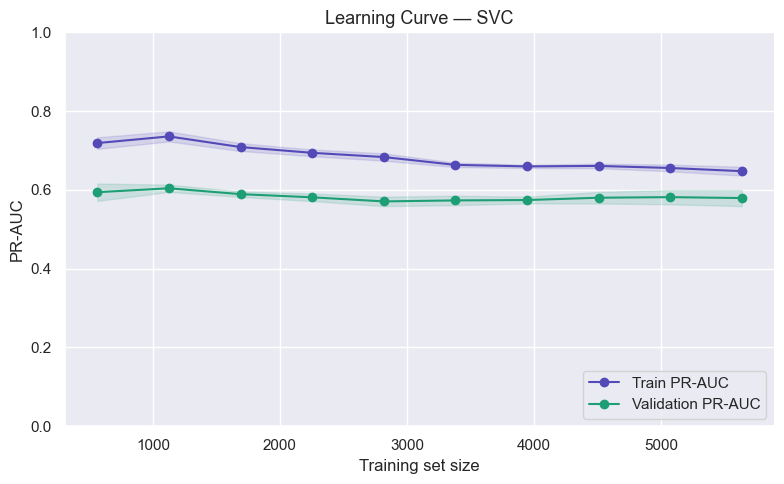

In [32]:
results_svc = train_svm_churn(df.drop('Churn', axis=1), df['Churn'])

# 8. Compare Results

## 8. 1. Train/Test Metrics

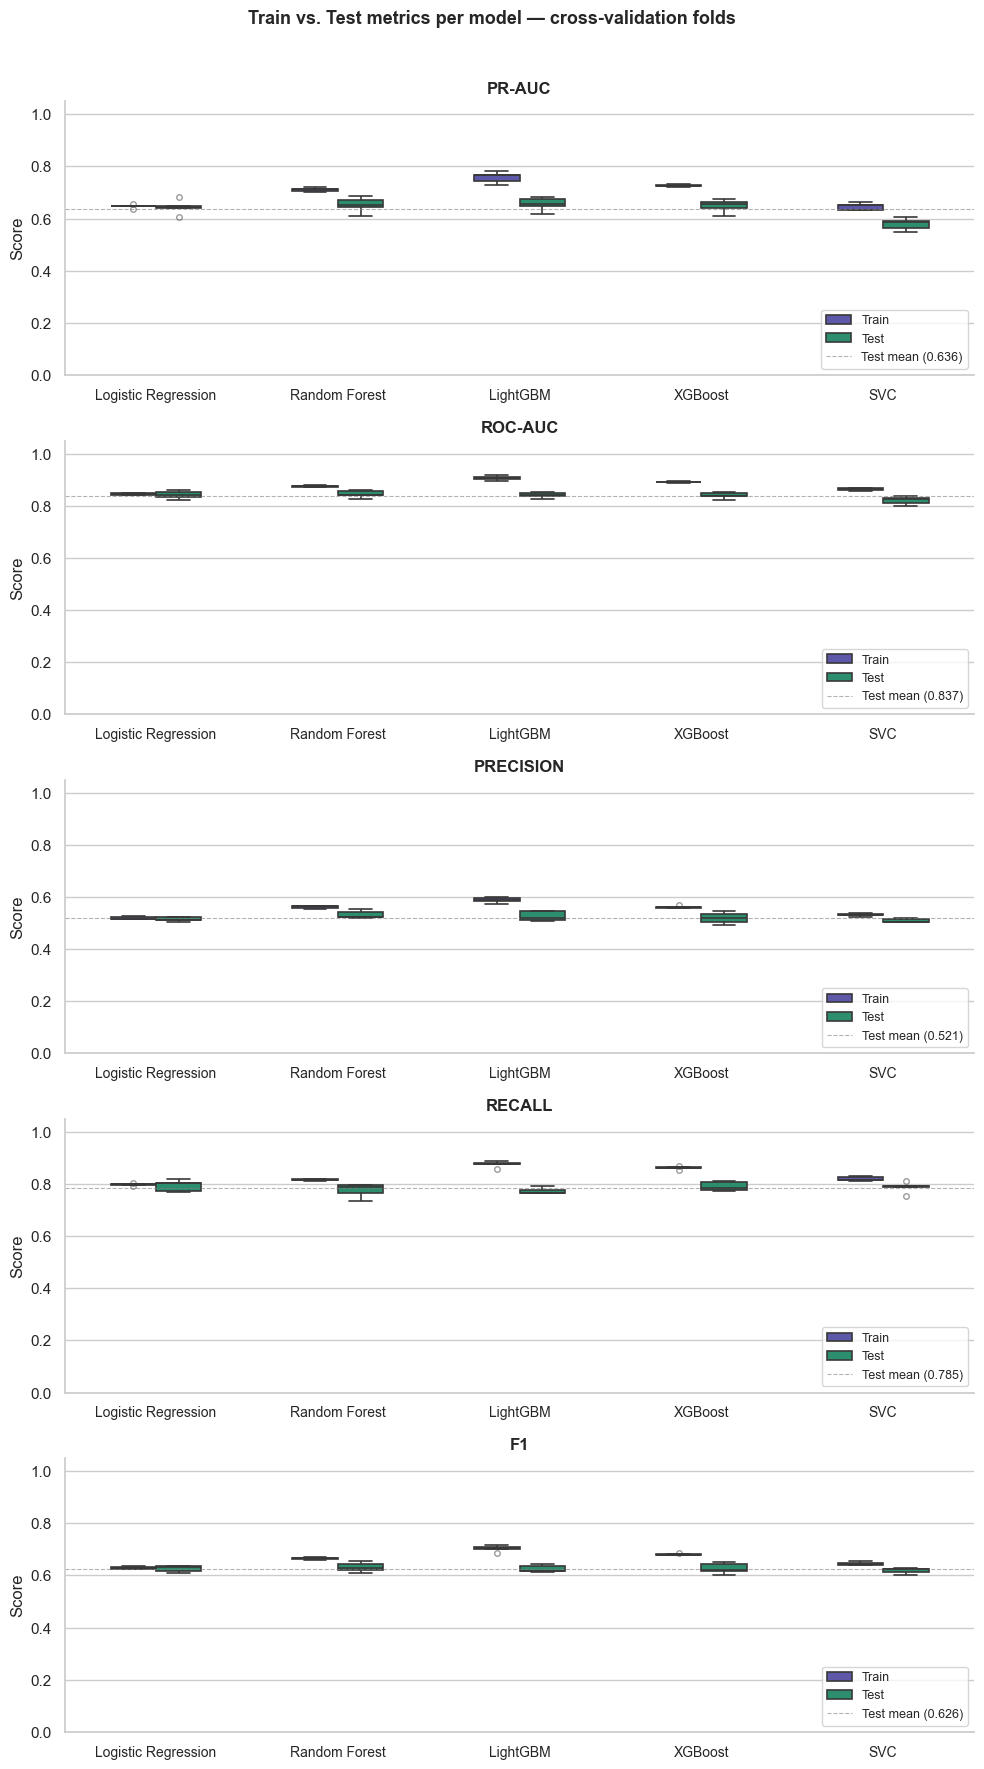

In [33]:
# ── Configuration ──────────────────────────────────────────────────────────────
 
# Map display name → result dict returned by each train_*_churn function
results = {
    "Logistic Regression": results_logistic_regression,
    "Random Forest":       results_random_forest,
    "LightGBM":            results_lgbm,
    "XGBoost":             results_xgboost,
    "SVC":                 results_svc,
}
 
metrics = ["pr_auc", "roc_auc", "precision", "recall", "f1"]
 
# ── Build long-format DataFrame ────────────────────────────────────────────────
 
records = []
 
for model_name, result in results.items():
    for split, key in [("Train", "train_metrics"), ("Test", "val_metrics")]:
        df_metrics = result[key].copy()
 
        # Drop non-metric columns present in some models (e.g. best_iteration)
        available_metrics = [m for m in metrics if m in df_metrics.columns]
        df_metrics = df_metrics[available_metrics]
 
        for fold_idx, row in df_metrics.iterrows():
            for metric, value in row.items():
                records.append({
                    "model":  model_name,
                    "split":  split,
                    "metric": metric,
                    "value":  value,
                    "fold":   fold_idx,
                })
 
plot_df = pd.DataFrame(records)
 
# ── Plot ───────────────────────────────────────────────────────────────────────
 
sns.set_theme(style="whitegrid", palette="muted")
 
n_metrics = len(metrics)
fig, axes = plt.subplots(
    nrows=n_metrics,
    ncols=1,
    figsize=(max(10, len(results) * 2), n_metrics * 3.5),
)
 
palette = {"Train": "#534AB7", "Test": "#1D9E75"}
 
for ax, metric in zip(axes, metrics):
    metric_df = plot_df[plot_df["metric"] == metric]
 
    sns.boxplot(
        data=metric_df,
        x="model",
        y="value",
        hue="split",
        palette=palette,
        width=0.5,
        linewidth=1.2,
        flierprops={"marker": "o", "markersize": 4, "alpha": 0.5},
        ax=ax,
    )
 
    # Reference line at the overall validation mean across all models
    val_mean = metric_df[metric_df["split"] == "Test"]["value"].mean()
    ax.axhline(
        y=val_mean,
        color="gray",
        linestyle="--",
        linewidth=0.8,
        alpha=0.6,
        label=f"Test mean ({val_mean:.3f})",
    )
 
    ax.set_title(metric.upper().replace("_", "-"), fontsize=12, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("Score")
    ax.set_ylim(0, 1.05)
    ax.legend(loc="lower right", fontsize=9)
    ax.tick_params(axis="x", labelsize=10)
    sns.despine(ax=ax)
 
fig.suptitle(
    "Train vs. Test metrics per model — cross-validation folds",
    fontsize=13,
    fontweight="bold",
    y=1.01,
)
plt.tight_layout()
plt.show()

In [34]:
metrics = ["pr_auc", "roc_auc", "precision", "recall", "f1"]
 
# ── Build summary tables ───────────────────────────────────────────────────────
 
train_summary = pd.DataFrame({
    model_name: result["train_metrics"][
        [m for m in metrics if m in result["train_metrics"].columns]
    ].mean()
    for model_name, result in results.items()
}).T
 
val_summary = pd.DataFrame({
    model_name: result["val_metrics"][
        [m for m in metrics if m in result["val_metrics"].columns]
    ].mean()
    for model_name, result in results.items()
}).T
 
# ── Display ────────────────────────────────────────────────────────────────────
 
print("=" * 62)
print("TRAIN — mean metrics across CV folds")
print("=" * 62)
display(train_summary.style.highlight_max(axis=0, color="#ffffff"))
 
print()
 
print("=" * 62)
print("TEST — mean metrics across CV folds")
print("=" * 62)
display(val_summary.style.highlight_max(axis=0, color="#ffffff"))

TRAIN — mean metrics across CV folds


,pr_auc,roc_auc,precision,recall,f1
Logistic Regression,0.647386,0.845173,0.519511,0.799090,0.629653
Random Forest,0.711194,0.875193,0.560781,0.817817,0.665334
LightGBM,0.757953,0.906084,0.588647,0.876671,0.704340
XGBoost,0.726442,0.890920,0.561870,0.862359,0.680398
SVC,0.647451,0.863746,0.531776,0.820223,0.645208



TEST — mean metrics across CV folds


,pr_auc,roc_auc,precision,recall,f1
Logistic Regression,0.645020,0.842289,0.515079,0.794529,0.624946
Random Forest,0.653105,0.845221,0.532338,0.776863,0.631669
LightGBM,0.655856,0.840767,0.526187,0.774213,0.626433
XGBoost,0.649093,0.839145,0.519882,0.791323,0.627428
SVC,0.579258,0.820069,0.509369,0.788103,0.618720


The models' behavior is relatively similar: they present lower precision (slightly above 50%) and higher recall (close to 80%). This indicates that, on the test sets, the models were able to identify most customers who would churn, but at the cost of generating a high number of churn predictions. This is not necessarily an issue if the operational cost of targeting customers classified as potential churn cases is not significant.

## 8. 2. Business KPIs

In [40]:
results = {
    "Logistic Regression": result,
    "Random Forest":       results_random_forest,
    "LightGBM":            results_lgbm,
    "XGBoost":             results_xgboost,
    "SVM":                 results_svc,
}

THRESHOLD       = 0.5   # churn probability cutoff
SAVE_RATE       = 0.30  # % of contacted customers successfully retained
COST_PER_ACTION = 15.0  # cost per retention action
FOLD_IDX        = -1    # which CV fold to use

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

df_input = df.drop("Churn", axis=1)
y = df["Churn"]

splits = list(cv.split(df_input, y))
_, val_idx = splits[FOLD_IDX]

X_val = df_input.iloc[val_idx]
y_val = y.iloc[val_idx]

# Financial data for the validation fold
val_financial = df.loc[val_idx, :].copy()
val_financial["churn_real"] = y_val.values

# Baseline metrics (no model — no retention action)
n_total           = len(val_financial)
churn_rate_base   = val_financial["churn_real"].mean()
mrr_base          = val_financial["MonthlyCharges"].sum()
mrr_lost_base     = val_financial[val_financial["churn_real"] == 1]["MonthlyCharges"].sum()
mrr_retained_base = mrr_base - mrr_lost_base
ltv_base          = (val_financial["MonthlyCharges"] * val_financial["tenure"]).sum()

records = []

# Baseline row — no model, no action
records.append({
    "model":            "Baseline (no action)",
    "churners_avoided": 0,
    "churn_rate":       round(churn_rate_base, 4),
    "mrr_total":        round(mrr_base, 2),
    "mrr_retained":     round(mrr_retained_base, 2),
    "mrr_lost":         round(mrr_lost_base, 2),
    "ltv_total":        round(ltv_base, 2),
})

for model_name, res in results.items():
    model   = res["models"][FOLD_IDX]
    encoder = res.get("encoders", [None])[FOLD_IDX]

    # ── Apply one-hot encoding with the fold's fitted encoder ──────────────────
    # Each model stores the encoder fitted on its training fold. Applying it
    # here ensures X_val is transformed identically to how the model saw data
    # during training — categories unseen in training become all-zero rows.
    if encoder is not None:
        categorical_cols   = X_val.select_dtypes(include=["object", "category"]).columns.tolist()
        numeric_cols       = X_val.select_dtypes(exclude=["object", "category"]).columns.tolist()

        X_val_cat          = encoder.transform(X_val[categorical_cols])
        X_val_encoded      = np.hstack([X_val[numeric_cols].values, X_val_cat])
    else:
        # Model was trained without categorical columns or encoding was
        # handled internally (e.g. pipeline already contains the encoder)
        X_val_encoded = X_val.values

    # ── Score — route by model type ────────────────────────────────────────────

    if hasattr(model, "predict_proba"):
        churn_score = model.predict_proba(X_val_encoded)[:, 1]
    elif isinstance(model, lgb.Booster):
        churn_score = model.predict(X_val_encoded)
    elif isinstance(model, xgb.Booster):
        feature_names = res.get("feature_names", None)
        dval = xgb.DMatrix(
            X_val_encoded,
            feature_names=feature_names if feature_names else list(X_val.columns),
        )
        churn_score = model.predict(dval)
    else:
        raise TypeError(f"Unsupported model type: {type(model)}")

    churn_pred = (churn_score >= THRESHOLD).astype(int)

    eval_df = val_financial.copy()
    eval_df["churn_score"] = churn_score
    eval_df["churn_pred"]  = churn_pred

    # ── Simulate retention outcome ─────────────────────────────────────────────

    # True positives: correctly flagged churners — SAVE_RATE of them are retained
    true_pos_mask  = (eval_df["churn_pred"] == 1) & (eval_df["churn_real"] == 1)
    false_pos_mask = (eval_df["churn_pred"] == 1) & (eval_df["churn_real"] == 0)
    false_neg_mask = (eval_df["churn_pred"] == 0) & (eval_df["churn_real"] == 1)

    n_true_pos  = true_pos_mask.sum()
    n_false_neg = false_neg_mask.sum()

    # Churners avoided = true positives retained by the campaign
    churners_avoided = int(n_true_pos * SAVE_RATE)

    # Effective churners after retention action
    # = real churners - those successfully retained by the campaign
    effective_churners = val_financial["churn_real"].sum() - churners_avoided

    # Post-retention churn rate
    churn_rate_post = effective_churners / n_total

    # MRR recovered: MonthlyCharges of retained true positives
    tp_charges    = eval_df.loc[true_pos_mask, "MonthlyCharges"]
    mrr_recovered = tp_charges.sample(
        n=churners_avoided, random_state=42
    ).sum() if churners_avoided > 0 else 0.0

    mrr_lost_post     = mrr_lost_base - mrr_recovered
    mrr_retained_post = mrr_base - mrr_lost_post

    # LTV: retained customers accumulate more tenure.
    # Approximation: saved customers contribute one additional month of MRR to LTV.
    ltv_post = ltv_base + mrr_recovered

    records.append({
        "model":            model_name,
        "churners_avoided": churners_avoided,
        "churn_rate":       round(churn_rate_post,   4),
        "mrr_total":        round(mrr_base,          2),
        "mrr_retained":     round(mrr_retained_post, 2),
        "mrr_lost":         round(mrr_lost_post,     2),
        "ltv_total":        round(ltv_post,          2),
    })

# ── Display ────────────────────────────────────────────────────────────────────

summary_df = pd.DataFrame(records).set_index("model")

print("=" * 72)
print("POST-RETENTION BUSINESS METRICS PER MODEL")
print(f"Assumptions: threshold={THRESHOLD} | save_rate={SAVE_RATE:.0%} | cost_per_action=${COST_PER_ACTION}")
print("=" * 72)
display(summary_df.style.highlight_max(axis=0, color="#ffffff"))

print()
print("=" * 72)
print("DELTA vs. BASELINE (no action)")
print("=" * 72)

baseline = summary_df.loc["Baseline (no action)"]
delta_df  = summary_df.drop("Baseline (no action)").copy()

delta_df["churn_rate_delta"]   = (delta_df["churn_rate"]    - baseline["churn_rate"]).round(4)
delta_df["mrr_retained_delta"] = (delta_df["mrr_retained"]  - baseline["mrr_retained"]).round(2)
delta_df["mrr_lost_delta"]     = (delta_df["mrr_lost"]      - baseline["mrr_lost"]).round(2)
delta_df["ltv_delta"]          = (delta_df["ltv_total"]     - baseline["ltv_total"]).round(2)

display(delta_df[[
    "churners_avoided",
    "churn_rate_delta",
    "mrr_retained_delta",
    "mrr_lost_delta",
    "ltv_delta",
]].style.highlight_max(axis=0, color="#ffffff"))

POST-RETENTION BUSINESS METRICS PER MODEL
Assumptions: threshold=0.5 | save_rate=30% | cost_per_action=$15.0


,churners_avoided,churn_rate,mrr_total,mrr_retained,mrr_lost,ltv_total
model,,,,,,
Baseline (no action),0,0.265600,88666.200000,60906.200000,27760.000000,3050228.950000
Logistic Regression,0,0.265600,88666.200000,60906.200000,27760.000000,3050228.950000
Random Forest,86,0.204500,88666.200000,67415.450000,21250.750000,3056738.200000
LightGBM,86,0.204500,88666.200000,67435.500000,21230.700000,3056758.250000
XGBoost,87,0.203800,88666.200000,67595.450000,21070.750000,3056918.200000
SVM,0,0.265600,88666.200000,60906.200000,27760.000000,3050228.950000



DELTA vs. BASELINE (no action)


,churners_avoided,churn_rate_delta,mrr_retained_delta,mrr_lost_delta,ltv_delta
model,,,,,
Logistic Regression,0,0.000000,0.000000,0.000000,0.000000
Random Forest,86,-0.061100,6509.250000,-6509.250000,6509.250000
LightGBM,86,-0.061100,6529.300000,-6529.300000,6529.300000
XGBoost,87,-0.061800,6689.250000,-6689.250000,6689.250000
SVM,0,0.000000,0.000000,0.000000,0.000000


# 9. Conclusions

If the model were used for customer prioritization, assuming a 30% retention success rate and a uniform intervention effect, XGBoost would be the model with the greatest expected business impact, achieving the largest reduction in churn rate (a 6.18% decrease) while retaining the highest amount of MRR (US$ 6,689.25).